<a href="https://www.kaggle.com/code/shivalabs/kmeans-dbscan-hierarchical-gmm-tsne?scriptVersionId=347827376" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


# Problem Statement
You own the mall and want to understand the customers like who can be easily converge [Target Customers] so that the sense can be given to marketing team and plan the strategy accordingly.


Informaly : Which customers are our target customers, and what marketing strategy should we use for them?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv",index_col = 'CustomerID')

In [4]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [5]:
df.rename(columns={"Annual Income (k$)":"Annual Income","Spending Score (1-100)":"Spending Score"},inplace=True)


In [6]:
df.shape

(200, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200 entries, 1 to 200
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Gender          200 non-null    object
 1   Age             200 non-null    int64 
 2   Annual Income   200 non-null    int64 
 3   Spending Score  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 7.8+ KB


In [8]:
df.isna().sum()

Gender            0
Age               0
Annual Income     0
Spending Score    0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

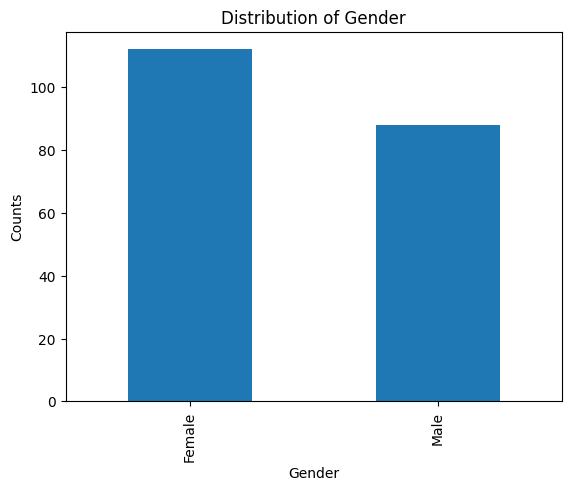

In [10]:
df['Gender'].value_counts().plot(kind='bar',xlabel="Gender",ylabel='Counts',title="Distribution of Gender")
plt.show()

In `Gender` Column Female is comparative higher

In [11]:
df.describe()

,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


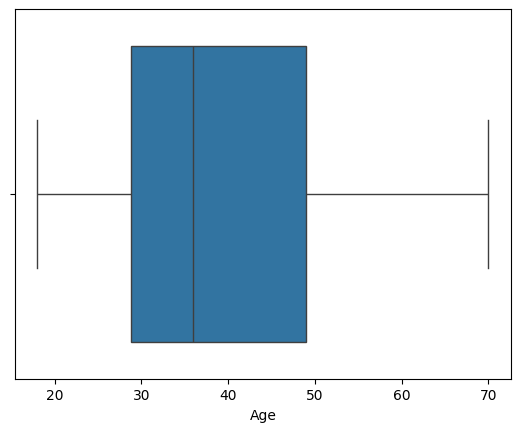

In [12]:
sns.boxplot(data=df,x='Age')
plt.show()

No outlier value in Age

In [13]:
q1 = df["Age"].quantile(0.25)
q3 = df['Age'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * (IQR)
upper_bound = q3 + 1.5 * (IQR)

df[((df['Age'] < lower_bound) | (df['Age'] > upper_bound))]

,Gender,Age,Annual Income,Spending Score
CustomerID,,,,


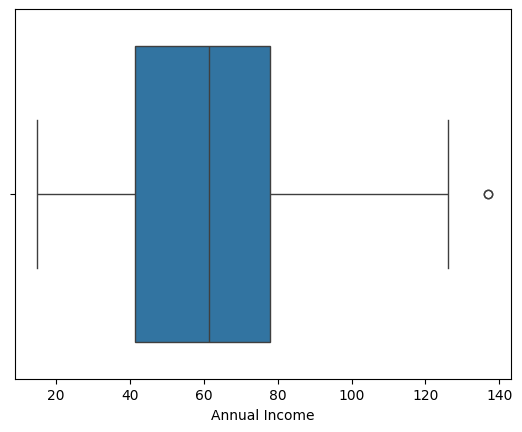

In [14]:
sns.boxplot(data=df,x='Annual Income')
plt.show()

In annual Income contains outlier value

In [15]:
q1 = df["Annual Income"].quantile(0.25)
q3 = df['Annual Income'].quantile(0.75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * (IQR)
upper_bound = q3 + 1.5 * (IQR)

df[((df['Annual Income'] < lower_bound) | (df['Annual Income'] > upper_bound))]

,Gender,Age,Annual Income,Spending Score
CustomerID,,,,
199,Male,32,137,18
200,Male,30,137,83


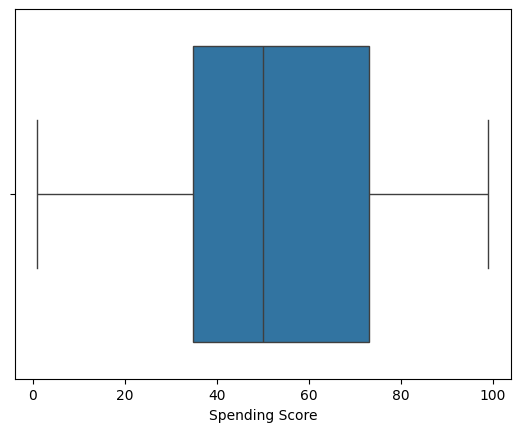

In [16]:
sns.boxplot(data=df,x='Spending Score')
plt.show()

No outlier values

In [17]:
print(df[['Age','Annual Income','Spending Score']].skew())


Age               0.485569
Annual Income     0.321843
Spending Score   -0.047220
dtype: float64


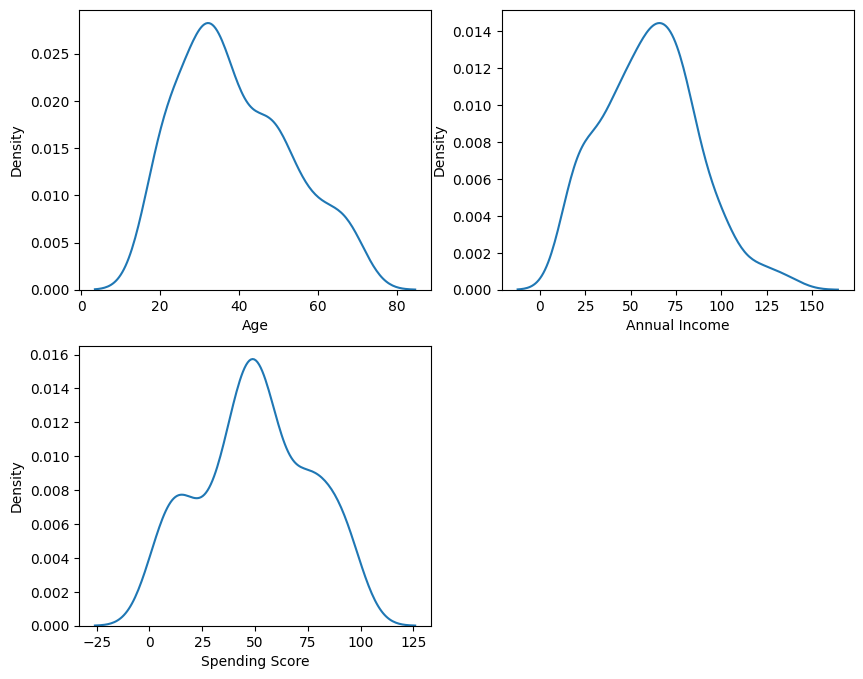

In [18]:
fig = plt.figure(figsize=(10,8))

ax1 = fig.add_subplot(2,2,1)
sns.kdeplot(data=df,x='Age',ax=ax1) # low right skewed

ax2 = fig.add_subplot(2,2,2)
sns.kdeplot(data=df,x='Annual Income',ax=ax2) # low right skewed

ax3 = fig.add_subplot(2,2,3)
sns.kdeplot(data=df,x='Spending Score',ax=ax3) # low left skewed


plt.show()

Age, Annual Income and Spending Score have low skewness

In [19]:
df.head()

,Gender,Age,Annual Income,Spending Score
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


# Preprocessing

In [20]:
from sklearn.preprocessing import StandardScaler


In [21]:
num_cols = df.select_dtypes(include='int64').columns
ss = StandardScaler()
X = ss.fit_transform(df[num_cols])

# KMeans

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


wcss = []
silhouette_scores = []

for i in range(2,10):
    kmeans = KMeans(n_clusters=i,random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette = silhouette_score(X,labels)
    silhouette_scores.append(silhouette)
    wcss.append(kmeans.inertia_)

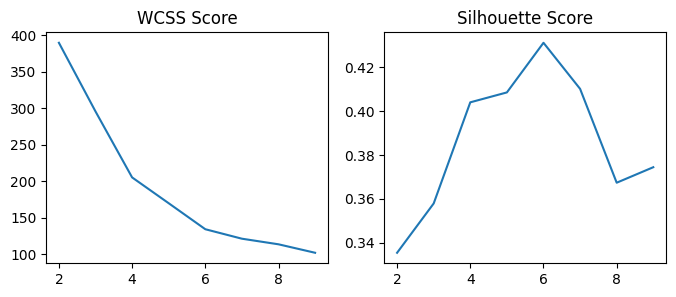

In [23]:
fig = plt.figure(figsize=(8,3))
ax1 = fig.add_subplot(1,2,1)
ax1.plot(np.arange(2,10),wcss)
ax1.set_title("WCSS Score")

ax2 = fig.add_subplot(1,2,2)
ax2.plot(np.arange(2,10),silhouette_scores)
ax2.set_title("Silhouette Score")
plt.show()

Elbow Method → ~6

Silhouette Score → 6

Therefore K = 6

In [24]:
max(silhouette_scores)

np.float64(0.43106526216603014)

# Prediction

In [25]:
kmeans = KMeans(n_clusters=6,random_state=42)
labels = kmeans.fit_predict(X)


In [26]:
df['labels'] = labels

# Visualization in 2d

In [27]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

In [28]:
pca_clusters = pca.transform(kmeans.cluster_centers_)

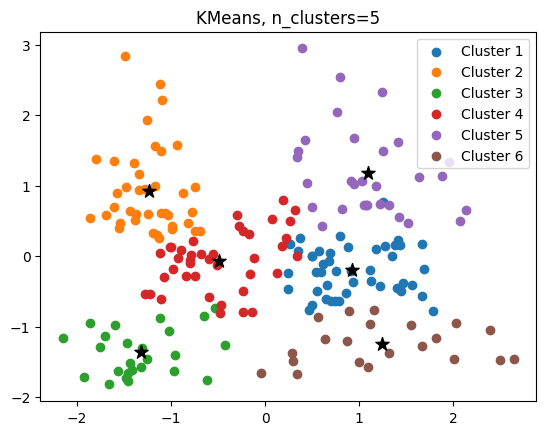

In [29]:
for i in range(6):
    plt.scatter(
        X_pca[labels == i, 0],
        X_pca[labels == i, 1],
        label=f"Cluster {i+1}"
    )

plt.scatter(pca_clusters[:,0],pca_clusters[:,1],marker="*",s=100,color='black')
plt.title("KMeans, n_clusters=5")
plt.legend()
plt.show()

Plotting using Seaborn

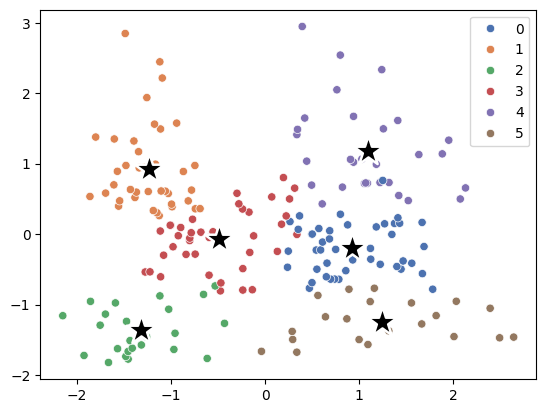

In [30]:
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=labels,palette="deep")
sns.scatterplot(x=pca_clusters[:,0],y=pca_clusters[:,1],marker="*",s=500,color='black')
plt.show()

# Revisit Problem Statement
Which customers are our target customers, and what marketing strategy should we use for them?

In [31]:
pd.crosstab(
    df["labels"],
    df["Gender"],
    normalize="index"
) * 100

# 56 percentage of cluster 2, are Female

Gender,Female,Male
labels,,
0,57.777778,42.222222
1,53.846154,46.153846
2,56.000000,44.000000
3,60.000000,40.000000
4,46.666667,53.333333
5,61.904762,38.095238


- Cluster 0 → 57.8% Female
- Cluster 1 → 53.8% Female
- Cluster 2 → 56.0% Female
- Cluster 3 → 60.0% Female
- Cluster 4 → 46.7% Female
- Cluster 5 → 61.9% Female

Nothing is extremely imbalanced, So We don't have a cluster that's overwhelmingly male or female.

That means Gender isn't giving you a strong segmentation story here.

In [32]:
cluster_profile = df.groupby("labels")[
    ["Age", "Annual Income", "Spending Score"]
].mean()

cluster_profile

,Age,Annual Income,Spending Score
labels,,,
0,56.333333,54.266667,49.066667
1,32.692308,86.538462,82.128205
2,25.560000,26.480000,76.240000
3,26.125000,59.425000,44.450000
4,44.000000,90.133333,17.933333
5,45.523810,26.285714,19.380952


- Cluster 1 is the highest-priority customer segment because these customers have high purchasing power and already demonstrate high spending behavior.

- Cluster 4 represents a potentially valuable conversion opportunity: customers have high income but currently show very low spending.

- Cluster 2 These are young customers who spend a lot despite relatively low income.


We identified six distinct customer segments based on age, annual income, and spending behavior. Among them, 

Cluster 1 represents the most attractive existing target segment because it consists of relatively young customers with high income and high spending scores.


Cluster 4 represents another important opportunity because customers have high income but very low spending, suggesting potential for conversion through targeted marketing. 

Cluster 2 consists of young, high-spending customers with relatively low income, who may respond well to affordable and promotional offerings.

# DBSCAN

In [33]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.1, min_samples=5)
labels = dbscan.fit_predict(X)

# for using silhouette score, we need atleast 2 cluster


In [34]:
np.unique(labels, return_counts=True)

(array([-1]), array([200]))

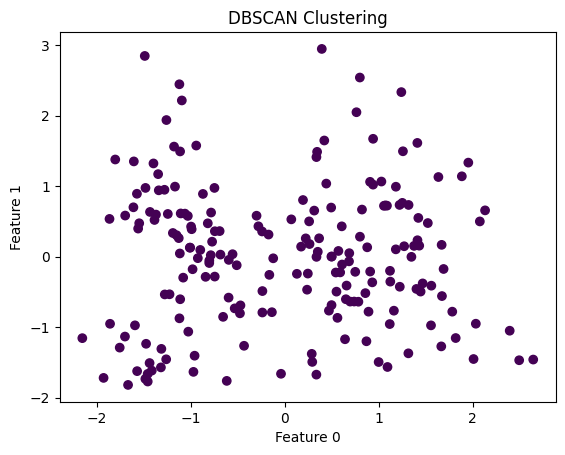

In [35]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Plotting
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', marker='o')
plt.title("DBSCAN Clustering")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()



In [36]:
eps_val = 1
min_val = 3
dbscan = DBSCAN(eps=eps_val, min_samples=min_val)
labels = dbscan.fit_predict(X)

print(np.unique(labels, return_counts=True))
print(silhouette_score(X,labels))

(array([-1,  0]), array([  1, 199]))
0.2513714457428386


# Hierarchical Clustering

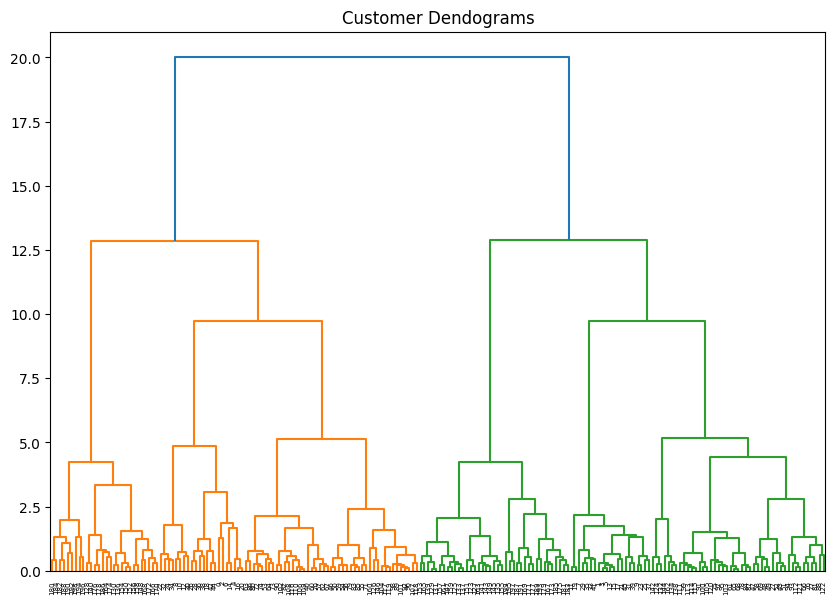

In [37]:
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10,7))

plt.title('Customer Dendograms')
dend = shc.dendrogram(shc.linkage(X,method='ward'))

- Choosing n_clusters = 2

In [38]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=2,metric='euclidean',linkage='ward')
labels_ = cluster.fit_predict(X)

In [39]:
np.unique(labels_,return_counts=True)

(array([0, 1]), array([105,  95]))

In [40]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_scaled = pca.fit_transform(X)


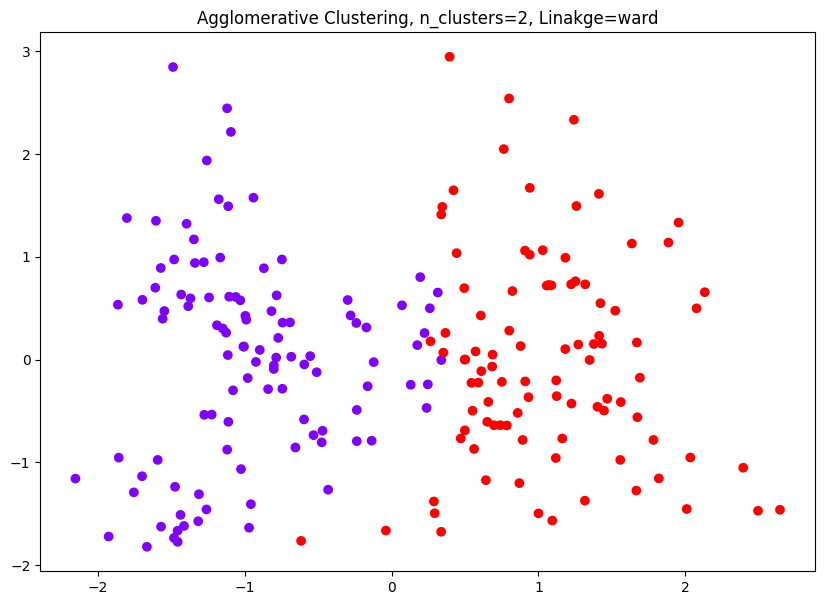

In [41]:
plt.figure(figsize=(10,7))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels_,cmap='rainbow')
plt.title('Agglomerative Clustering, n_clusters=2, Linakge=ward')
plt.show()

- choosing clusters = 5
> 1. Linkage=ward

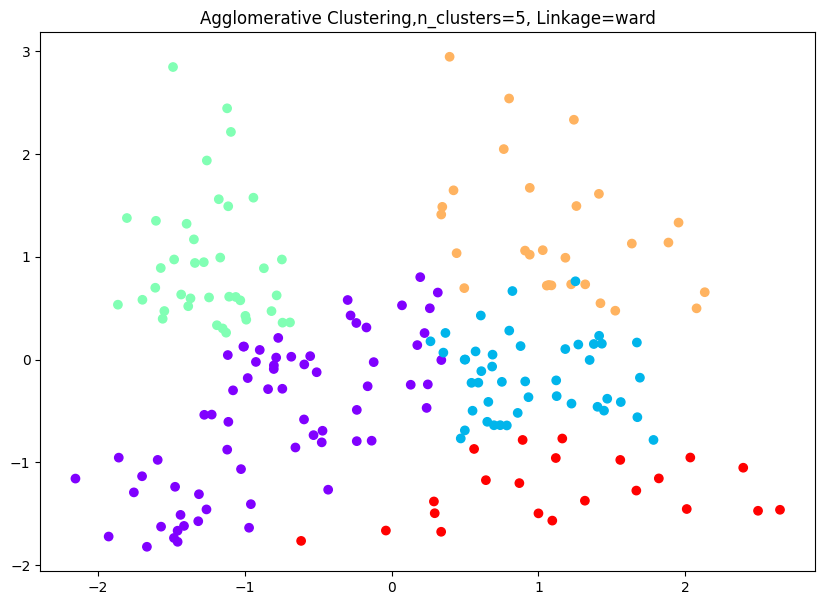

0.39002826186267214


In [42]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='ward')
labels_ = cluster.fit_predict(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_scaled = pca.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels_,cmap='rainbow')
plt.title("Agglomerative Clustering,n_clusters=5, Linkage=ward")
plt.show()

print(silhouette_score(X,labels_))

> ```2. Linkage = complete```

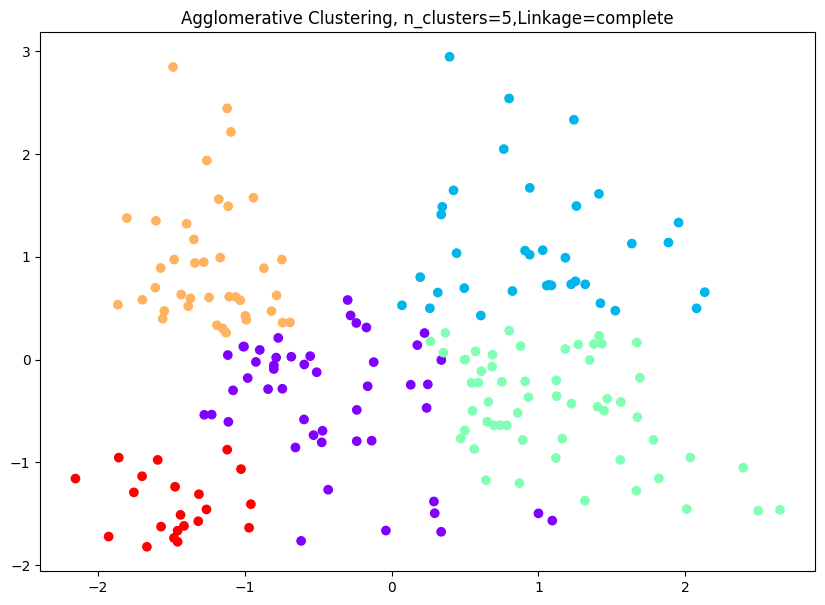

0.3999821356530837


In [43]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='complete')
labels_ = cluster.fit_predict(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_scaled = pca.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels_,cmap='rainbow')
plt.title("Agglomerative Clustering, n_clusters=5,Linkage=complete")
plt.show()

print(silhouette_score(X,labels_))

> Linkage=Average

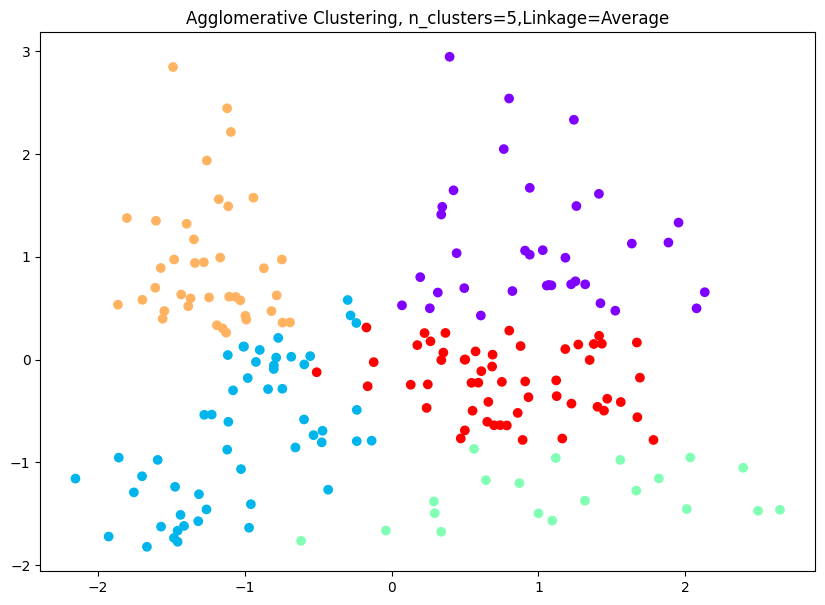

0.40956924875250705


In [44]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='average')
labels_ = cluster.fit_predict(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_scaled = pca.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels_,cmap='rainbow')
plt.title("Agglomerative Clustering, n_clusters=5,Linkage=Average")
plt.show()

print(silhouette_score(X,labels_))

> Linkage=single

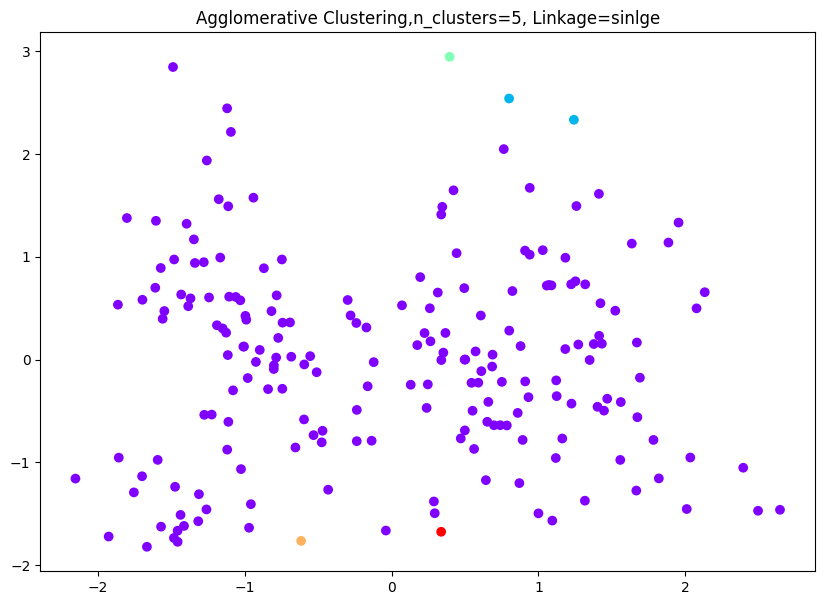

0.0030237255251292527


In [45]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='single')
labels_ = cluster.fit_predict(X)

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_scaled = pca.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels_,cmap='rainbow')
plt.title("Agglomerative Clustering,n_clusters=5, Linkage=sinlge")
plt.show()

print(silhouette_score(X,labels_))

# Using TSNE

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


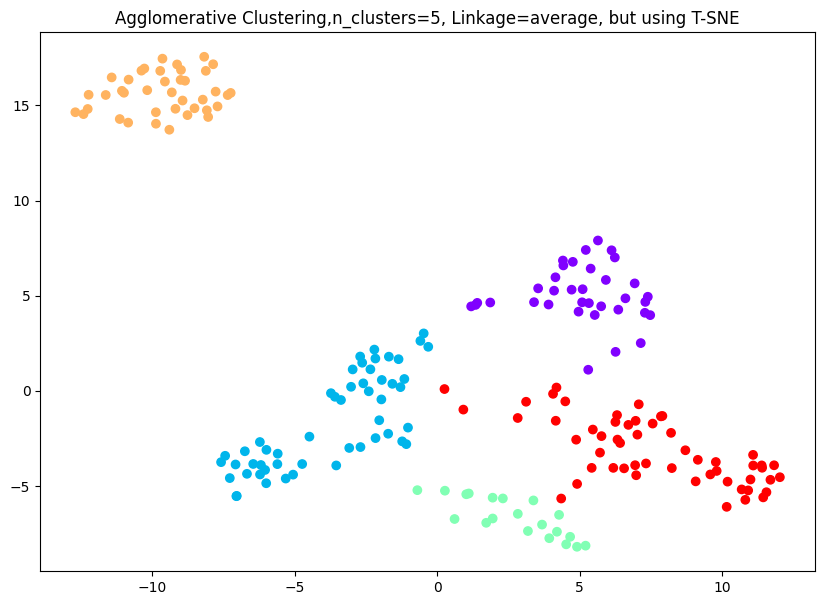

0.40956924875250705


In [46]:
from sklearn.cluster import AgglomerativeClustering

cluster = AgglomerativeClustering(n_clusters=5,metric='euclidean',linkage='average')
labels_ = cluster.fit_predict(X)

from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_scaled = tsne.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels_,cmap='rainbow')
plt.title("Agglomerative Clustering,n_clusters=5, Linkage=average, but using T-SNE")
plt.show()

print(silhouette_score(X,labels_))

# GMM

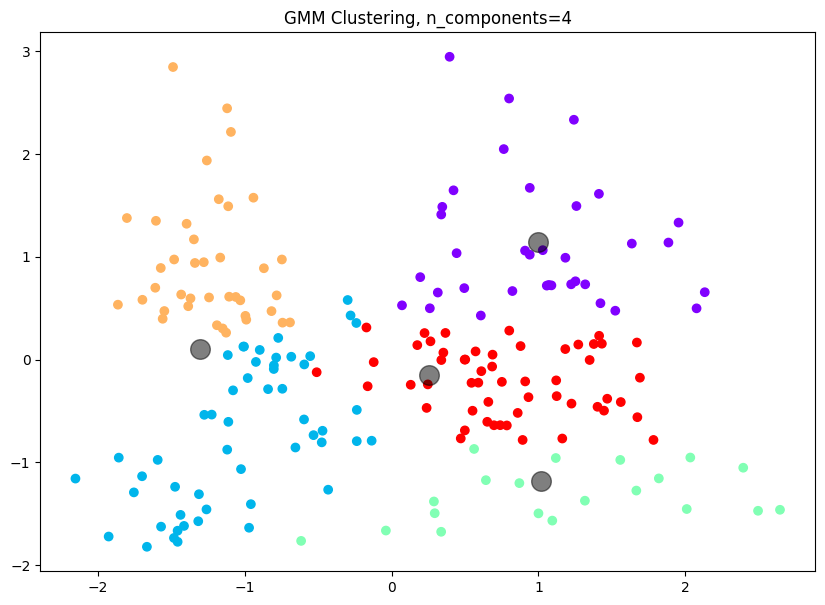

In [47]:
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, random_state=0).fit(X)
lables_ = gmm.predict(X)
centers = gmm.means_

from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_scaled = pca.fit_transform(X)
center_scaled = pca.transform(centers)

plt.figure(figsize=(10,7))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=labels_,cmap='rainbow')
plt.scatter(center_scaled[:, 0], center_scaled[:, 1], c='black', s=200, alpha=0.5)
plt.title("GMM Clustering, n_components=4")
plt.show()

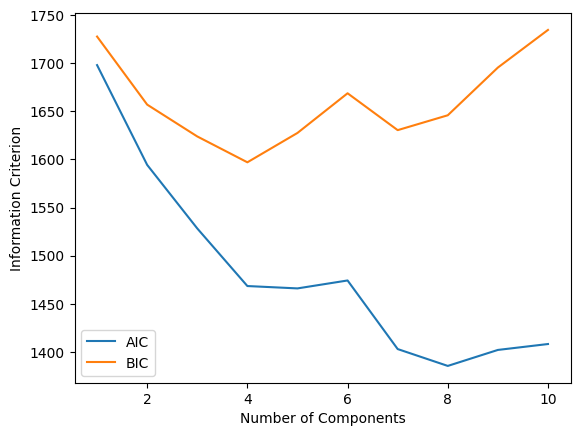

In [48]:
# Try GMMs with 1 to N components
N = 10
aics = []
bics = []
for i in range(1, N+1):
    gmm = GaussianMixture(n_components=i).fit(X)
    aics.append(gmm.aic(X))
    bics.append(gmm.bic(X))

# Plotting the AIC and BIC
plt.plot(range(1, N+1), aics, label='AIC')
plt.plot(range(1, N+1), bics, label='BIC')
plt.legend()
plt.xlabel('Number of Components')
plt.ylabel('Information Criterion')
plt.show()
